<a href="https://colab.research.google.com/github/fmlazohcc/ITAI-1371-ML-Labs/blob/main/FP_Airline_Sentiment_FernandoLazo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Sentiment Analysis of U.S. Airline Tweets

**Final Project**  
**Student:** Fernando Lazo -
ITSE 1371 Summer

---

## 🎯 Project Overview

This notebook completes an end-to-end sentiment analysis project. It explores customer tweets, cleans text, creates TF-IDF features, trains two classification models, compares their results, and explains how the findings could support an airline's customer-service decisions.


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Project Definition

**Business Problem:**

Airlines receive thousands of customer comments through social media. Reading every message manually takes time and may delay a response to an unhappy customer. The business problem in this project is to build a machine-learning model that can automatically classify airline tweets as **positive, neutral, or negative**. This could help an airline identify complaints more quickly, understand general customer opinion, and decide which messages need immediate attention.

---

**Dataset Description:**

- **Dataset name:** Twitter US Airline Sentiment
- **Source:** Public airline sentiment dataset supplied for this project
- **File used:** `Tweets.csv`
- **Number of records:** 14,640 tweets
- **Text column:** `text`
- **Target column:** `airline_sentiment`
- **Sentiment classes:** negative, neutral, and positive
- **Other useful columns:** airline name, negative reason, sentiment confidence, retweet count, and tweet date

**Why sentiment analysis is valuable:**

Sentiment analysis changes written customer feedback into information that can be counted and compared. An airline could use the results to find frequent complaints, measure public reaction, prioritize negative messages, and track whether customer sentiment improves over time.


---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [39]:
# Import the libraries used in this project.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

# Hide minor warning messages so the notebook is easier to read.
warnings.filterwarnings('ignore')

# Use a clean chart style.
plt.rcParams['figure.dpi'] = 100


In [40]:
import os

# Path to my Google Drive content folder.
# This project uses a subfolder in the drive called 'Colab Notebooks'.
drive_path = '/content/drive/MyDrive/Colab Notebooks'

# Change the current working directory to the drive path.
# I could have loaded this at run time, but instead placed it in folder
if os.path.exists(drive_path):
    os.chdir(drive_path)
    print(f'Current working directory changed to: {os.getcwd()}')
else:
    print(f'Warning: Drive path not found: {drive_path}. Please ensure Google Drive is mounted and the path is correct.')

# Load the CSV file into a pandas DataFrame called df.
# Note to self - A DataFrame is a table made of rows and columns.
df = pd.read_csv('Tweets.csv')

print(f'Dataset shape: {df.shape[0]:,} rows and {df.shape[1]} columns')
print('\nColumn names:')
print(df.columns.tolist())

# Display the first five rows to understand how the data is organized.
df.head()

Current working directory changed to: /content/drive/MyDrive/Colab Notebooks
Dataset shape: 14,640 rows and 15 columns

Column names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [41]:
# Check the data types and missing values.
# Note to self - missing values are blank entries in the dataset.
print('Dataset information:')
df.info()

print('\nMissing values in each column:')
print(df.isnull().sum().sort_values(ascending=False))

# Check whether any complete rows are duplicated.
print(f'\nNumber of duplicated rows: {df.duplicated().sum()}')
print(f"Missing tweet text values: {df['text'].isnull().sum()}")
print(f"Missing sentiment labels: {df['airline_sentiment'].isnull().sum()}")


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non

In [42]:
# Dataset is small enough to use on a normal computer,
# so no sample is needed for the final analysis.
# Create a focused copy containing the columns used most often.
project_df = df[['airline_sentiment', 'text', 'airline', 'negativereason']].copy()

print(f'Rows used in the project: {len(project_df):,}')
project_df.head()


Rows used in the project: 14,640


,airline_sentiment,text,airline,negativereason
0,neutral,@VirginAmerica What @dhepburn said.,Virgin America,NaN
1,positive,@VirginAmerica plus you've added commercials t...,Virgin America,NaN
2,neutral,@VirginAmerica I didn't today... Must mean I n...,Virgin America,NaN
3,negative,@VirginAmerica it's really aggressive to blast...,Virgin America,Bad Flight
4,negative,@VirginAmerica and it's a really big bad thing...,Virgin America,Can't Tell


                   Tweet Count  Percentage
airline_sentiment                         
negative                  9178       62.69
neutral                   3099       21.17
positive                  2363       16.14


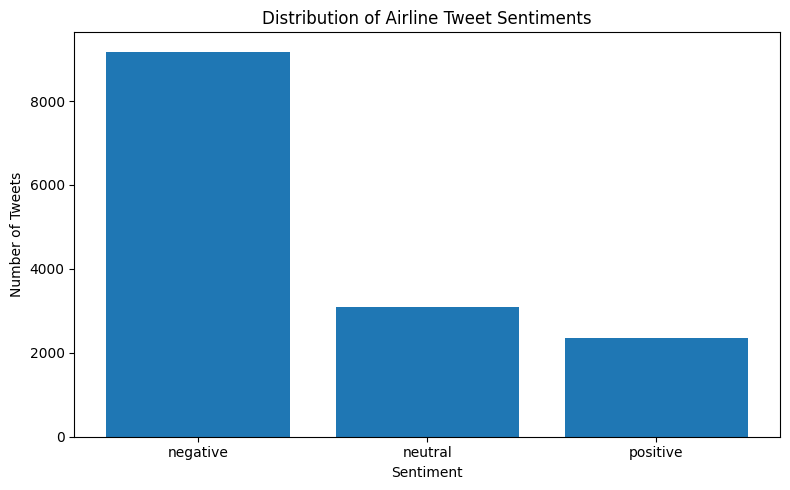

In [43]:
# Count how many tweets belong to each sentiment class.
sentiment_counts = project_df['airline_sentiment'].value_counts()
sentiment_percent = project_df['airline_sentiment'].value_counts(normalize=True).mul(100).round(2)

sentiment_summary = pd.DataFrame({
    'Tweet Count': sentiment_counts,
    'Percentage': sentiment_percent
})
print(sentiment_summary)

# Create a bar chart to make the class imbalance easy to see.
plt.figure(figsize=(8, 5))
ordered_counts = sentiment_counts.reindex(['negative', 'neutral', 'positive'])
plt.bar(ordered_counts.index, ordered_counts.values)
plt.title('Distribution of Airline Tweet Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()


### 📊 Interpretation: Class Balance

The sentiment classes are **not balanced**. Negative tweets make up about 62.69% of the dataset, neutral tweets about 21.17%, and positive tweets about 16.14%. Because negative tweets are the largest group, a model may become better at predicting negative messages than positive or neutral messages.

To reduce misleading results, this project uses a **stratified train-test split**, which keeps approximately the same class percentages in the training and test sets. The evaluation also includes precision, recall, F1-score, and confusion matrices instead of relying only on accuracy.


Overall tweet length statistics:
       character_length  word_count
count          14640.00    14640.00
mean             103.82       17.65
std               36.28        6.88
min               12.00        2.00
25%               77.00       12.00
50%              114.00       19.00
75%              136.00       23.00
max              186.00       36.00

Average length by sentiment:
                   character_length  word_count
airline_sentiment                              
negative                     113.95       19.69
neutral                       87.36       14.41
positive                      86.08       14.01


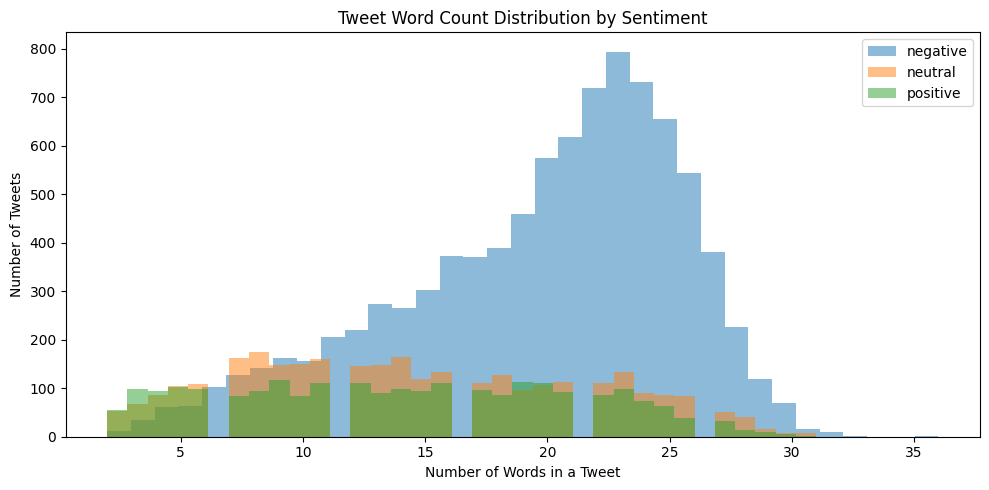

In [44]:
# Measure tweet length in characters and in words.
project_df['character_length'] = project_df['text'].str.len()
project_df['word_count'] = project_df['text'].str.split().str.len()

print('Overall tweet length statistics:')
print(project_df[['character_length', 'word_count']].describe().round(2))

print('\nAverage length by sentiment:')
print(project_df.groupby('airline_sentiment')[['character_length', 'word_count']].mean().round(2))

# Plot the distribution of word counts.
plt.figure(figsize=(10, 5))
for sentiment in ['negative', 'neutral', 'positive']:
    values = project_df.loc[project_df['airline_sentiment'] == sentiment, 'word_count']
    plt.hist(values, bins=35, alpha=0.5, label=sentiment)
plt.legend()
plt.title('Tweet Word Count Distribution by Sentiment')
plt.xlabel('Number of Words in a Tweet')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()


### 📊 Interpretation: Text Length

Most tweets are short because Twitter limits message length. In this dataset, tweets contain roughly 17 words on average. Negative tweets are slightly longer on average than positive tweets, which may happen because customers often provide more details when describing a problem.

There are some very short messages and some much longer messages. TF-IDF can still process both, although extremely short tweets may not contain enough context for a correct prediction.


In [45]:
# Display three example tweets from each sentiment class.
# random_state makes the same examples appear each time the notebook runs.
for sentiment in ['negative', 'neutral', 'positive']:
    print('\n' + '=' * 70)
    print(f'{sentiment.upper()} TWEET EXAMPLES')
    print('=' * 70)
    examples = project_df[project_df['airline_sentiment'] == sentiment].sample(3, random_state=42)
    for tweet in examples['text']:
        print('-', tweet)



NEGATIVE TWEET EXAMPLES
- @united gate C 24 IAD. U released passengers to board w/others deplaning .50 peopleOn bridge while next flight  board http://t.co/HfoF33iyhi
- @USAirways 1729 connecting in charlotte to houston. Mechanical issue determined while q'd to take off. And we checked our bags.
- @united installed and working are not the same. Kicked me out after an hour and wouldn't let me back in. Four wasted hours.

NEUTRAL TWEET EXAMPLES
- @united we finally just arrive to Bogota, good but long flight!!
- @AmericanAir got a callback at 1 am, took care of it. thanks.
- @JetBlue is there wifi on he plain

POSITIVE TWEET EXAMPLES
- @SouthwestAir thanks for your excellent response time and assistance! All set :)
- @JetBlue thanks. I appreciate your prompt response.
- @JetBlue yes, with about 20 minutes to spare.  FYI - your employees are amazing.  Keep up the good work!


            Word  Count
0         united   4159
1         flight   3949
2      usairways   3053
3    americanair   2963
4   southwestair   2458
5        jetblue   2366
6            not   1587
7             no   1510
8           http   1155
9         thanks   1082
10     cancelled   1065
11          just    973
12       service    965
13          help    874
14          time    792
15      customer    754
16           i'm    688
17         hours    684
18           amp    683
19       flights    649


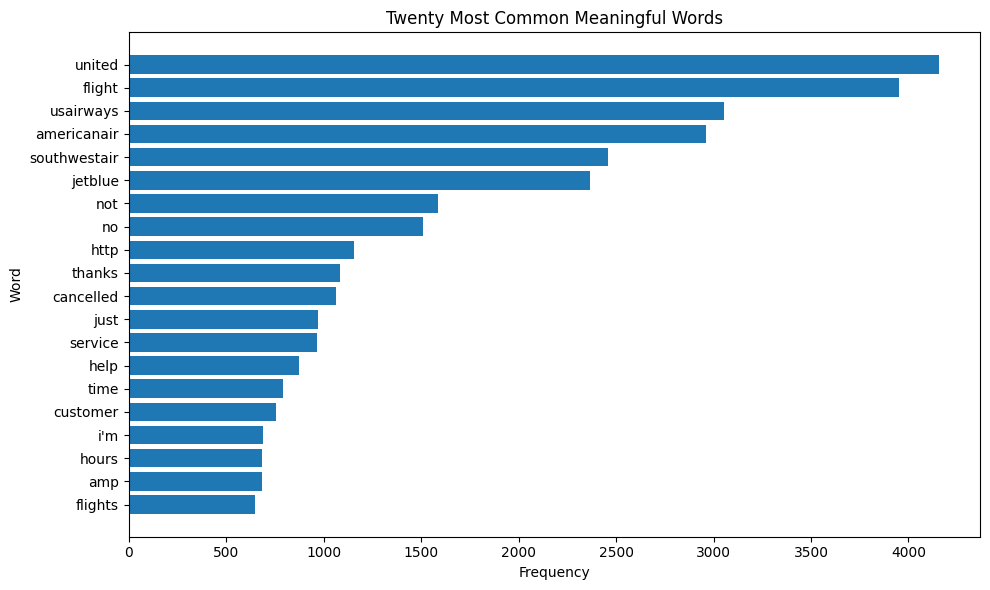

In [14]:
# Perform a simple common-word analysis before formal preprocessing.
# Note to self - these stopwords are common English words that usually
# add little meaning.
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

# Keep negation words because words such as "not" can change sentiment.
stop_words_for_eda = set(ENGLISH_STOP_WORDS) - {'no', 'not', 'nor'}

def basic_words(text):
    # Convert to lowercase and keep alphabetic words with at least two letters.
    words = re.findall(r"[a-zA-Z']{2,}", str(text).lower())
    return [word for word in words if word not in stop_words_for_eda]

all_words = []
for tweet in project_df['text']:
    all_words.extend(basic_words(tweet))

common_words = pd.DataFrame(Counter(all_words).most_common(20), columns=['Word', 'Count'])
print(common_words)

plt.figure(figsize=(10, 6))
plt.barh(common_words['Word'][::-1], common_words['Count'][::-1])
plt.title('Twenty Most Common Meaningful Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


### 📝 EDA Summary

1. **Dataset characteristics:** The dataset contains 14,640 tweets about major U.S. airlines. Each tweet is labeled negative, neutral, or positive.
2. **Data quality issues:** The two required columns, `text` and `airline_sentiment`, do not contain missing values. Several optional columns contain many missing values, but they are not needed for the main text classification model.
3. **Key patterns observed:** Negative tweets are the largest class. Tweets are generally short, and negative tweets tend to be slightly longer. Common words include airline names and travel-related terms.
4. **Potential challenges:** Class imbalance may cause weaker predictions for positive and neutral tweets. Tweets also include usernames, links, abbreviations, misspellings, sarcasm, and limited context.


---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [47]:
# Import tools for cleaning text, splitting data, and creating TF-IDF features.
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Remove most common English stopwords, but keep negation words.
# "Not good" means something different from "good," so "not" is important.
custom_stop_words = set(ENGLISH_STOP_WORDS) - {'no', 'not', 'nor'}


In [48]:
# Create a function that cleans one tweet at a time.
def preprocess_text(text):
    """
    Clean a tweet and return a simpler version for machine learning.

    Steps:
    1. Convert text to lowercase.
    2. Remove website links.
    3. Remove Twitter usernames such as @AmericanAir.
    4. Keep the word inside a hashtag but remove the # symbol.
    5. Remove numbers and punctuation.
    6. Remove common stopwords, while keeping no/not/nor.
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)       # Remove links
    text = re.sub(r'@\w+', ' ', text)                 # Remove usernames
    text = re.sub(r'#(\w+)', r'\1', text)             # Keep hashtag word
    text = re.sub(r"[^a-z\s']", " ", text)           # Keep letters and apostrophes
    text = re.sub(r'\s+', ' ', text).strip()           # Remove extra spaces

    words = [word for word in text.split() if word not in custom_stop_words]
    return ' '.join(words)

# Show a quick example of the cleaning function.
example_tweet = project_df['text'].iloc[0]
print('Original:', example_tweet)
print('Cleaned: ', preprocess_text(example_tweet))


Original: @VirginAmerica What @dhepburn said.
Cleaned:  said


In [49]:
# Apply the cleaning function to every tweet.
project_df['cleaned_text'] = project_df['text'].apply(preprocess_text)

# Check for tweets that became empty after cleaning.
empty_cleaned = (project_df['cleaned_text'].str.len() == 0).sum()
print(f'Empty tweets after cleaning: {empty_cleaned}')

# Compare original and cleaned text.
project_df[['text', 'cleaned_text']].head(10)


Empty tweets after cleaning: 48


,text,cleaned_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus you've added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didn't today mean need trip
3,@VirginAmerica it's really aggressive to blast...,it's really aggressive blast obnoxious enterta...
4,@VirginAmerica and it's a really big bad thing...,it's really big bad thing
5,@VirginAmerica seriously would pay $30 a fligh...,seriously pay flight seats didn't playing it's...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly time fly vx ear worm won t away
7,@VirginAmerica Really missed a prime opportuni...,really missed prime opportunity men hats parody
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",didn't d
9,"@VirginAmerica it was amazing, and arrived an ...",amazing arrived hour early you're good


In [50]:
# X contains the information used to make predictions.
# y contains the correct sentiment labels the model must learn.
X = project_df['cleaned_text']
y = project_df['airline_sentiment']

print('Feature data shape:', X.shape)
print('Target data shape:', y.shape)
print('\nTarget labels:')
print(y.value_counts())


Feature data shape: (14640,)
Target data shape: (14640,)

Target labels:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [51]:
# Split the data into training and testing groups.
# Training data teaches the models; test data checks unseen performance.
# stratify=y keeps the sentiment proportions similar in both groups.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training tweets: {len(X_train):,}')
print(f'Testing tweets: {len(X_test):,}')
print('\nTraining class percentages:')
print(y_train.value_counts(normalize=True).mul(100).round(2))


Training tweets: 11,712
Testing tweets: 2,928

Training class percentages:
airline_sentiment
negative    62.70
neutral     21.17
positive    16.14
Name: proportion, dtype: float64


In [52]:
# TF-IDF changes words into numerical features that models can understand.
# Important words receive larger values, while very common words receive less weight.
tfidf = TfidfVectorizer(
    max_features=5000,     # Use no more than the 5,000 most useful features
    ngram_range=(1, 2),    # Include single words and two-word phrases
    min_df=2,              # Ignore terms that appear in only one tweet
    sublinear_tf=True      # Reduce the effect of repeated words in one tweet
)

# Learn the vocabulary only from training data to avoid data leakage.
X_train_tfidf = tfidf.fit_transform(X_train)

# Apply the same learned vocabulary to the test data.
X_test_tfidf = tfidf.transform(X_test)

print('Training TF-IDF shape:', X_train_tfidf.shape)
print('Testing TF-IDF shape:', X_test_tfidf.shape)


Training TF-IDF shape: (11712, 5000)
Testing TF-IDF shape: (2928, 5000)


In [53]:
# View a sample of the words and phrases selected by TF-IDF.
feature_names = tfidf.get_feature_names_out()
print(f'Total TF-IDF features: {len(feature_names):,}')
print('\nFirst 30 features:')
print(feature_names[:30])
print('\nExample two-word features:')
print([feature for feature in feature_names if ' ' in feature][:20])


Total TF-IDF features: 5,000

First 30 features:
['aa' 'aa customer' 'aa dfw' 'aa does' 'aa flight' 'aa no' 'aa not'
 'aadvantage' 'abc' 'ability' 'able' 'able change' 'able check'
 'able help' 'able reach' 'able rebook' 'able use' 'aboard' 'abq'
 'absolute' 'absolute worst' 'absolutely' 'absurd' 'abt' 'abysmal'
 'accept' 'acceptable' 'accepted' 'accepting' 'access']

Example two-word features:
['aa customer', 'aa dfw', 'aa does', 'aa flight', 'aa no', 'aa not', 'able change', 'able check', 'able help', 'able reach', 'able rebook', 'able use', 'absolute worst', 'access journal', 'account help', 'actually flight', 'actually work', 'address issue', 'address thanks', 'admirals club']


### 📝 Preprocessing Summary

1. **Preprocessing steps applied:** Lowercasing, removing links and usernames, removing punctuation and numbers, keeping hashtag words, removing extra spaces, and removing common stopwords. Negation words such as *not* were kept because they can change sentiment.
2. **TF-IDF parameters chosen:** `max_features=5000`, `ngram_range=(1, 2)`, `min_df=2`, and `sublinear_tf=True`.
3. **Final feature count:** Up to 5,000 numerical word and phrase features.
4. **Rationale:** These settings keep the model manageable while allowing it to learn both individual words and useful two-word phrases such as “not happy.” TF-IDF was fitted only on the training data to prevent data leakage.


---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [54]:
# Import the classification models and a timer.
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import time


## Model 1: Logistic Regression

In [23]:
# Train Model 1: Logistic Regression.
# This model learns weights that connect TF-IDF features to sentiment classes.
print('Training Logistic Regression...')
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Give smaller classes more importance during training
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

lr_training_time = time.time() - start_time
print(f'Logistic Regression training time: {lr_training_time:.2f} seconds')


Training Logistic Regression...
Logistic Regression training time: 3.81 seconds


In [55]:
# Ask Logistic Regression to predict the sentiment of the unseen test tweets.
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f'Number of Logistic Regression predictions: {len(y_pred_lr):,}')
print('First 10 predictions:', y_pred_lr[:10])


Number of Logistic Regression predictions: 2,928
First 10 predictions: ['negative' 'positive' 'negative' 'negative' 'negative' 'negative'
 'neutral' 'negative' 'negative' 'neutral']


## Model 2: Multinomial Naive Bayes

In [56]:
# Train Model 2: Multinomial Naive Bayes.
# This model uses word probabilities to decide which sentiment is most likely.
print('Training Multinomial Naive Bayes...')
start_time = time.time()

nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

nb_training_time = time.time() - start_time
print(f'Naive Bayes training time: {nb_training_time:.2f} seconds')


Training Multinomial Naive Bayes...
Naive Bayes training time: 0.05 seconds


In [26]:
# Ask Naive Bayes to predict the sentiment of the unseen test tweets.
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f'Number of Naive Bayes predictions: {len(y_pred_nb):,}')
print('First 10 predictions:', y_pred_nb[:10])


Number of Naive Bayes predictions: 2,928
First 10 predictions: ['negative' 'negative' 'negative' 'negative' 'negative' 'negative'
 'negative' 'negative' 'negative' 'negative']


## Model 3 (Optional)

A third model was not required. This project focuses on a clear comparison between Logistic Regression and Multinomial Naive Bayes, two efficient models that work well with TF-IDF text features.


In [57]:
# No third model is trained because the assignment requires at least two models.
print('Two required models were trained: Logistic Regression and Multinomial Naive Bayes.')


Two required models were trained: Logistic Regression and Multinomial Naive Bayes.


### 📝 Model Training Summary

| Model | Main Parameters | Notes |
|---|---|---|
| Logistic Regression | `max_iter=1000`, `class_weight='balanced'` | Uses weighted classes to reduce the effect of class imbalance. |
| Multinomial Naive Bayes | `alpha=0.5` | Fast probability-based model commonly used for text classification. |

The exact training times are printed by the code because they may be different on each computer.


---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [58]:
# Import measurements used to evaluate classification models.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Keep the same class order in reports and confusion matrices.
class_labels = ['negative', 'neutral', 'positive']


## Evaluate Model 1: Logistic Regression

In [59]:
# Calculate Logistic Regression performance measurements.
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print('=' * 60)
print('LOGISTIC REGRESSION RESULTS')
print('=' * 60)
print(f'Accuracy:           {lr_accuracy:.4f}')
print(f'Weighted Precision: {lr_precision:.4f}')
print(f'Weighted Recall:    {lr_recall:.4f}')
print(f'Weighted F1-score:  {lr_f1:.4f}')
print('\nDetailed classification report:')
print(classification_report(y_test, y_pred_lr, labels=class_labels, zero_division=0))


LOGISTIC REGRESSION RESULTS
Accuracy:           0.7671
Weighted Precision: 0.7900
Weighted Recall:    0.7671
Weighted F1-score:  0.7746

Detailed classification report:
              precision    recall  f1-score   support

    negative       0.90      0.80      0.85      1835
     neutral       0.55      0.71      0.62       620
    positive       0.69      0.71      0.70       473

    accuracy                           0.77      2928
   macro avg       0.71      0.74      0.72      2928
weighted avg       0.79      0.77      0.77      2928



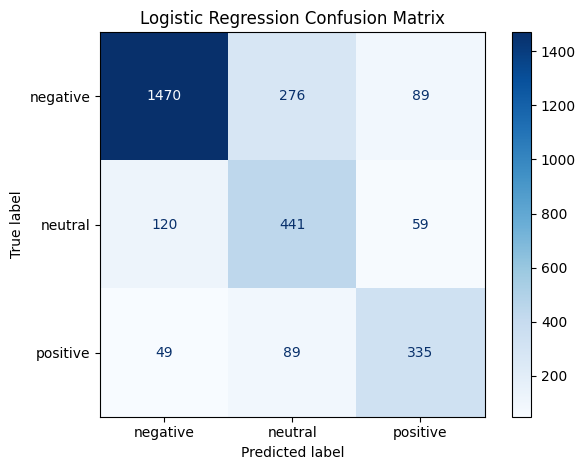

In [60]:
# A confusion matrix shows correct and incorrect predictions for each class.
lr_cm = confusion_matrix(y_test, y_pred_lr, labels=class_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=class_labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression Confusion Matrix')
plt.grid(False)
plt.tight_layout()
plt.show()


### 📊 Interpretation: Logistic Regression

1. **Overall performance:** Logistic Regression produces strong overall results and performs more evenly across the three sentiment classes than a model that simply favors the largest class.
2. **Strengths:** It identifies negative tweets well and also finds a meaningful portion of neutral and positive tweets. The balanced class setting helps the smaller classes receive attention.
3. **Weaknesses:** Neutral tweets are difficult because they may contain both positive and negative language or may simply ask a question. Positive tweets are also less common, so the model has fewer examples from which to learn.
4. **Confusion matrix insights:** Most correct predictions appear on the main diagonal. The largest errors generally involve neutral tweets being confused with negative or positive tweets.


## Evaluate Model 2: Naive Bayes

In [61]:
# Calculate Naive Bayes performance measurements.
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print('=' * 60)
print('MULTINOMIAL NAIVE BAYES RESULTS')
print('=' * 60)
print(f'Accuracy:           {nb_accuracy:.4f}')
print(f'Weighted Precision: {nb_precision:.4f}')
print(f'Weighted Recall:    {nb_recall:.4f}')
print(f'Weighted F1-score:  {nb_f1:.4f}')
print('\nDetailed classification report:')
print(classification_report(y_test, y_pred_nb, labels=class_labels, zero_division=0))


MULTINOMIAL NAIVE BAYES RESULTS
Accuracy:           0.7548
Weighted Precision: 0.7507
Weighted Recall:    0.7548
Weighted F1-score:  0.7240

Detailed classification report:
              precision    recall  f1-score   support

    negative       0.76      0.97      0.85      1835
     neutral       0.68      0.31      0.43       620
    positive       0.83      0.51      0.63       473

    accuracy                           0.75      2928
   macro avg       0.75      0.60      0.64      2928
weighted avg       0.75      0.75      0.72      2928



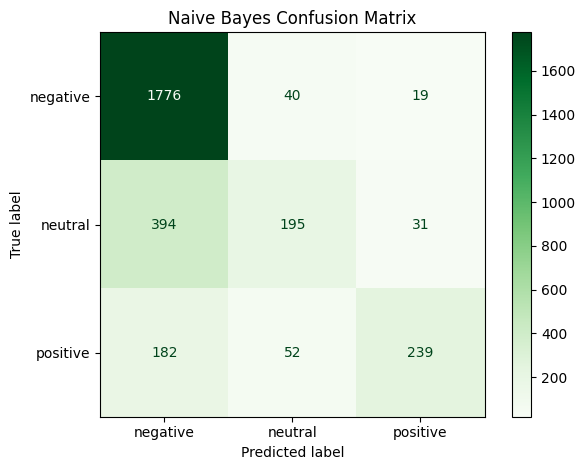

In [62]:
# Plot the Naive Bayes confusion matrix.
nb_cm = confusion_matrix(y_test, y_pred_nb, labels=class_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm, display_labels=class_labels)
disp.plot(cmap='Greens', values_format='d')
plt.title('Naive Bayes Confusion Matrix')
plt.grid(False)
plt.tight_layout()
plt.show()


### 📊 Interpretation: Naive Bayes

1. **Overall performance:** Naive Bayes is fast and produces a useful baseline, but its overall performance is lower than Logistic Regression in this project.
2. **Strengths:** It trains quickly and identifies many clearly negative tweets because certain complaint words strongly point toward the negative class.
3. **Weaknesses:** It tends to favor the negative class because negative examples are much more common. It has more difficulty separating neutral and positive tweets.
4. **Confusion matrix insights:** The matrix shows more neutral and positive tweets being incorrectly predicted as negative compared with Logistic Regression.


## Evaluate Model 3 (Optional)

No third model was trained.


In [63]:
print('No third model to evaluate.')


No third model to evaluate.


In [64]:
print('No third confusion matrix to display.')


No third confusion matrix to display.


## Model Comparison

In [65]:
# Put the main measurements into one comparison table.
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Multinomial Naive Bayes'],
    'Accuracy': [lr_accuracy, nb_accuracy],
    'Weighted Precision': [lr_precision, nb_precision],
    'Weighted Recall': [lr_recall, nb_recall],
    'Weighted F1-score': [lr_f1, nb_f1],
    'Training Time (seconds)': [lr_training_time, nb_training_time]
})

results.round(4)


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-score,Training Time (seconds)
0,Logistic Regression,0.7671,0.7900,0.7671,0.7746,3.8108
1,Multinomial Naive Bayes,0.7548,0.7507,0.7548,0.7240,0.0508


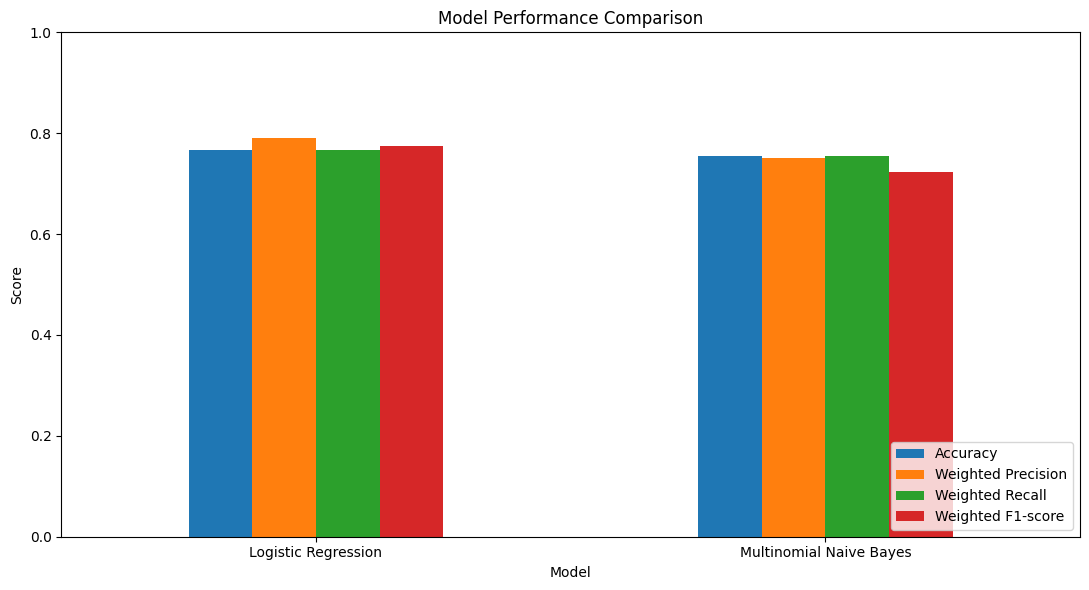

In [66]:
# Compare the four performance measurements in a bar chart.
plot_results = results.set_index('Model')[
    ['Accuracy', 'Weighted Precision', 'Weighted Recall', 'Weighted F1-score']
]

plot_results.plot(kind='bar', figsize=(11, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 📊 Model Comparison Analysis

1. **Which model performed best?** Logistic Regression performed best overall. It achieved the stronger weighted F1-score and a better balance among negative, neutral, and positive predictions.
2. **What metrics were prioritized and why?** Accuracy was considered, but weighted precision, recall, and F1-score were also important because the classes are imbalanced. The F1-score is especially useful because it combines precision and recall.
3. **Trade-offs:** Naive Bayes trained faster and is simple to understand, but Logistic Regression provided more dependable predictions across all three classes. For this business problem, a small increase in training time is acceptable if customer messages are classified more accurately.
4. **Business meaning:** Logistic Regression would be the better choice for helping an airline sort customer feedback. However, human review should still be used for urgent or unclear messages.


## Error Analysis (Optional but Recommended)

In [67]:
# Review a sample of Logistic Regression mistakes.
# This helps understand what the score alone cannot explain.
error_analysis = pd.DataFrame({
    'Original Tweet': project_df.loc[X_test.index, 'text'],
    'Cleaned Tweet': X_test,
    'Actual Sentiment': y_test,
    'Predicted Sentiment': y_pred_lr
})

misclassified = error_analysis[
    error_analysis['Actual Sentiment'] != error_analysis['Predicted Sentiment']
]

print(f'Total Logistic Regression errors: {len(misclassified):,} out of {len(y_test):,} test tweets')
misclassified.sample(min(10, len(misclassified)), random_state=42)


Total Logistic Regression errors: 682 out of 2,928 test tweets


,Original Tweet,Cleaned Tweet,Actual Sentiment,Predicted Sentiment
4218,@united who can tell me where they are?,tell,negative,neutral
4915,@SouthwestAir I requested my boarding pass to ...,requested boarding pass texted haven't received,negative,neutral
6041,@SouthwestAir Thanks! Will do,thanks,neutral,positive
1163,@united forces us to check our baby bag on ove...,forces check baby bag overbooked flight compla...,negative,neutral
12808,@AmericanAir Was not on board you today just w...,not board today just watched report unfold twi...,positive,negative
13255,@AmericanAir this is all i gotta say to y'all ...,gotta say y'all amp staff real,negative,positive
653,@united you have to follow me in order for me ...,follow order dm come,negative,neutral
12213,@AmericanAir Thank you for responding so quick...,thank responding quickly tweets appreciate,neutral,positive
11695,@USAirways This flight was for my brother. He ...,flight brother rebooked able info phone pass club,negative,neutral
9585,@USAirways I will. Is it down or is just me?,just,negative,positive


### 📊 Error Analysis Insights

1. **Common types of errors:** Neutral tweets are often confused with negative tweets, and some short positive tweets are predicted as neutral or negative.
2. **Why errors occur:** Tweets are short and may lack context. Sarcasm, slang, spelling errors, mixed feelings, and airline-specific names can make the true meaning difficult to detect. Removing usernames can also remove the airline name, although this prevents the model from depending too heavily on a specific account.
3. **Possible improvements:** More balanced training data, better handling of emojis and negation, airline-specific features, and advanced language models could improve performance. Human review could be added for predictions with low confidence.


---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

This project analyzed 14,640 tweets about major U.S. airlines and classified them as negative, neutral, or positive. The dataset showed that customer feedback was mostly negative, indicating that social media is frequently used to report airline problems. Two machine-learning models were trained using cleaned text and TF-IDF features. Logistic Regression performed better overall than Multinomial Naive Bayes and would be the preferred model for automatically sorting airline feedback, although uncertain or urgent complaints should still receive human review.


## 🎯 Key Findings

1. **Dataset insights:**
   - The dataset contains 14,640 labeled airline tweets.
   - Negative tweets are the majority class, followed by neutral and positive tweets.
   - Negative messages tend to be slightly longer because complaints often include details.

2. **Model performance:**
   - Both models learned useful patterns from TF-IDF word and phrase features.
   - Naive Bayes was very fast but tended to favor the negative class.
   - Logistic Regression produced a better balance across the three classes.

3. **Best model and why:**
   - Logistic Regression was selected because it had the stronger overall weighted metrics and confusion-matrix results.

4. **Surprising Discovery - Customer sentiment:**
   - The reviewed social media feedback was predominantly negative, suggesting that customers often contact airlines on Twitter when experiencing a problem.


## 💼 Business Recommendations

1. **Immediate applications:**
   - Use the model to automatically sort incoming tweets by sentiment.
   - Send negative tweets to customer-service staff for faster review.
   - Track frequent complaint words and negative reasons to identify repeated service problems.

2. **Who should use this model?**
   - Airline social-media teams, customer-service managers, and business analysts.

3. **Recommended workflow:**
   - Use Logistic Regression as an initial screening tool.
   - Prioritize negative messages, especially those involving cancellations, delays, lost baggage, or customer safety.
   - Keep a person involved when the message is unclear, urgent, or legally sensitive.

4. **Expected business value:**
   - Faster complaint response, better use of staff time, measurable sentiment trends, and earlier detection of service issues.


## ⚠️ Limitations

1. **Data limitations:**
   - The dataset represents tweets from a particular time period and may not represent current airline customers.
   - Negative tweets greatly outnumber positive tweets.
   - Twitter users may not represent all airline passengers.

2. **Model limitations:**
   - TF-IDF does not fully understand context, sarcasm, humor, or the order of all words.
   - The model may struggle with misspellings, slang, emojis, or mixed sentiment.
   - Accuracy and weighted scores can hide weaker performance for smaller classes, so class-level metrics must also be reviewed.

3. **Generalization limitations:**
   - A model trained on airline tweets may not work well for hotels, restaurants, or other industries without retraining.

4. **Ethical and operational considerations:**
   - Automated sentiment should support, not replace, human judgment.
   - Messages involving emergencies, discrimination, threats, or private customer information require careful human handling.


## 🚀 Future Improvements

1. **Data collection:**
   - Add newer tweets and collect more positive and neutral examples.
   - Include feedback from surveys, email, chat, and review websites.

2. **Feature engineering:**
   - Preserve and interpret emojis.
   - Add features for tweet length, airline name, negative reason, and time of posting.
   - Improve handling of negation and common airline abbreviations.

3. **Advanced models:**
   - Compare Support Vector Machines or gradient-boosting models.
   - Test transformer language models such as BERT when more computing resources are available.

4. **Deployment:**
   - Build a dashboard that shows sentiment by airline and over time.
   - Add prediction confidence and send uncertain tweets to a human reviewer.


## 🎓 Lessons Learned

1. **Technical skills gained:**
   - I learned how to load and inspect a real text dataset, clean tweets, create TF-IDF features, train classification models, and evaluate predictions with several metrics.

2. **Challenges overcome:**
   - The main challenges were class imbalance, noisy social-media text, and understanding why accuracy alone does not tell the complete story.

3. **What I would do differently:**
   - I would test more ways of handling emojis, abbreviations, and negation, and I would collect more positive and neutral examples.

4. **Business understanding gained:**
   - I learned that a model is useful only when its results are connected to a practical decision. In this case, sentiment analysis can help an airline prioritize customer feedback, but human review remains important.


---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*